# Task-1b

## Data preprocessing

In [ ]:
# IMPORTANT:
#   Whenever you start a new colab runtime, use the following code to download
#   the training dataset onto the runtime local storage.
#   This should take ~3-5 mins for the whole dataset.
#   You can then load data from the local storage (/content/data) into your colab
#   notebook using the `h5py` library (see example below).
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="train.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="events.csv", repo_type="dataset", local_dir="data")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


train.h5:   0%|          | 0.00/10.7G [00:00<?, ?B/s]

events.csv:   0%|          | 0.00/782k [00:00<?, ?B/s]

'data/events.csv'

In [ ]:
# Standard library imports
import os
import numpy as np
from itertools import cycle

# Third-party library imports
import h5py
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, ConvLSTM2D, Conv3D, Conv2D, UpSampling2D, TimeDistributed,
    LeakyReLU, Concatenate, MaxPooling2D, Multiply, Lambda, Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.losses import Loss

In [ ]:
def upsample(data, target_shape=(384, 384)):
    """
    Upsample data to target resolution.
    :param data: Original data, shape (height, width).
    :param target_shape: Target resolution (height, width).
    :return: Upsampled data.
    """
    zoom_factors = (target_shape[0] / data.shape[0], target_shape[1] / data.shape[1])
    return zoom(data, zoom_factors, order=1)

def extract_event_ids(file_path):
    """
    Extract all event IDs from the HDF5 file.
    :param file_path: HDF5 file path.
    :return: List of event IDs.
    """
    with h5py.File(file_path, "r") as f:
        return list(f.keys())

def standard_normalize(data):
    """
    Standard normalization: (data - mean) / std.
    Avoid division by zero by adding a small epsilon to std.
    """
    mean = np.mean(data)
    std = np.std(data)
    return (data - mean) / (std + 1e-8)

def min_max_normalize(data):
    """
    Min-Max normalization: (data - min) / (max - min).
    Avoid division by zero by adding a small epsilon to the denominator.
    """
    min_val = np.min(data)
    max_val = np.max(data)
    return (data - min_val) / (max_val - min_val + 1e-8)

def dynamic_data_generator(file_path, event_ids, batch_size=8, input_length=12, output_length=12, target_shape=(384, 384)):
    """
    Dynamically loads and processes data from HDF5 file for training and validation,
    with added standard normalization. Outputs have shape:
    - X_batch: (batch_size, input_length, height, width, 4)
    - Y_batch: (batch_size, output_length, height, width, 1)
    """
    event_cycle = cycle(event_ids)

    with h5py.File(file_path, "r") as f:
        while True:
            X_batch, Y_batch = [], []

            unique_event_ids = [next(event_cycle) for _ in range(batch_size)]

            for event_id in unique_event_ids:
                if event_id not in f:
                    raise ValueError(f"Event ID {event_id} not found in file.")

                # Load all datasets
                vis = f[event_id]["vis"][:]
                ir069 = f[event_id]["ir069"][:]
                ir107 = f[event_id]["ir107"][:]
                vil = f[event_id]["vil"][:]

                # Standardize each dataset
                vis = min_max_normalize(vis)
                ir069 = min_max_normalize(ir069)
                ir107 = min_max_normalize(ir107)
                vil = min_max_normalize(vil)

                # Randomly select a range of consecutive frames
                min_frames = min(vis.shape[0], ir069.shape[0], ir107.shape[0], vil.shape[0])
                start_frame = np.random.randint(0, min_frames - input_length - output_length + 1)
                input_frames = slice(start_frame, start_frame + input_length)
                output_frames = slice(start_frame + input_length, start_frame + input_length + output_length)

                # Upsample inputs and stack them along the channel axis
                X_resized = np.array([
                    np.stack([
                        upsample(vis[frame], target_shape),
                        upsample(ir069[frame], target_shape),
                        upsample(ir107[frame], target_shape),
                        upsample(vil[frame], target_shape)
                    ], axis=-1)  # Stack 4 features along the channel axis
                    for frame in range(input_frames.start, input_frames.stop)
                ])  # Shape: (input_length, height, width, 4)

                # Upsample outputs (only vil channel)
                Y_resized = np.array([
                    upsample(vil[frame], target_shape)
                    for frame in range(output_frames.start, output_frames.stop)
                ])  # Shape: (output_length, height, width)

                # Expand Y_resized channel dimension to match shape (output_length, height, width, 1)
                Y_resized = np.expand_dims(Y_resized, axis=-1)

                X_batch.append(X_resized)  # Shape: (input_length, height, width, 4)
                Y_batch.append(Y_resized)  # Shape: (output_length, height, width, 1)

            # Stack data into batch format
            yield np.array(X_batch), np.array(Y_batch)

In [ ]:
# Extract event IDs from train.h5
file_path = "data/train.h5"
event_ids = extract_event_ids(file_path)

# Split into training and validation sets
train_ids = event_ids[:640]
val_ids = event_ids[640:720]
test_ids = event_ids[720:]

# Create generators
train_generator = dynamic_data_generator(file_path, train_ids, batch_size=4)
val_generator = dynamic_data_generator(file_path, val_ids, batch_size=4)
test_generator = dynamic_data_generator(file_path, test_ids, batch_size=4)

# Check output shape for debugging
X_batch, Y_batch = next(train_generator)
print("Input batch shape:", X_batch.shape)
print("Output batch shape:", Y_batch.shape)

Input batch shape: (4, 12, 384, 384, 4)
Output batch shape: (4, 12, 384, 384, 1)


In [ ]:
@tf.keras.utils.register_keras_serializable(package="CustomLoss")
class MSE_SSIM_Loss(Loss):
    def __init__(self, alpha=0.9, beta=0.1, **kwargs):
        super().__init__(**kwargs)
        self.alpha = alpha
        self.beta = beta

    def call(self, y_true, y_pred):
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        ssim = tf.image.ssim(y_true, y_pred, max_val=1.0)
        return self.alpha * mse + self.beta * (1 - tf.reduce_mean(ssim))

    def get_config(self):
        config = super().get_config()
        config.update({"alpha": self.alpha, "beta": self.beta})
        return config

## Build model and training
**Already exist optimization**
<br>
Based on previous version, including changes:
- random_select starter of the frame
- learning rate adjustment
- loss function changes(mse+ssim)
- early stopping
- max_min normalization
- modify the layers of the network
<br><br>
The model architecture incorporates the concept of U-Net, featuring a symmetric structure in the encoder and decoder sections with skip connections for feature propagation. The model integrates spatiotemporal convolution (ConvLSTM2D), TimeDistributed layers, and attention mechanisms, making it well-suited for processing spatiotemporal data such as video sequences or temporal images.

In [ ]:
@tf.keras.utils.register_keras_serializable(package="CustomLayers")
def attention(x):
    """ Temporal attention mechanism that assigns higher weight to later frames. """
    batch_size = tf.shape(x)[0]
    t_weight = tf.range(1, 13, dtype=tf.float32) / 12.0  # Generate weights for 12 frames
    t_weight = tf.reshape(t_weight, (1, 12, 1, 1, 1))
    t_weight = tf.tile(t_weight, [batch_size, 1, 1, 1, x.shape[-1]])  # Expand along batch and channel dimensions
    return Multiply()([x, t_weight])

def temporal_attention_layer():
    """ Applies the temporal attention mechanism using a Lambda layer. """
    return Lambda(attention, name="temporal_attention")

@tf.keras.utils.register_keras_serializable(package="CustomLayers")
class RecursiveLSTMLayer(tf.keras.layers.Layer):
    """ Recursive ConvLSTM2D layer to predict future frames (t=13 to t=24). """
    def __init__(self, units, output_length, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.output_length = output_length
        self.lstm = ConvLSTM2D(units, (3, 3), activation=None, padding='same', return_sequences=True)

    def call(self, inputs):
        outputs = []
        x = inputs[:, -1:, :, :, :]  # Use only the last frame (t=12) as the initial input
        for _ in range(self.output_length):
            x = self.lstm(x)  # Recursively feed the predicted frame back into LSTM
            outputs.append(x)

        return tf.concat(outputs, axis=1)  # Concatenate all predicted frames along the time axis

def unet_convlstm_recursive(input_shape=(12, 384, 384, 4), output_length=12):
    """ U-Net + ConvLSTM2D model for frame prediction. """
    inputs = Input(shape=input_shape, name="input_layer")

    # ** Encoding Path**
    conv1 = TimeDistributed(Conv2D(16, (3, 3), activation=None, padding='same'))(inputs)
    conv1 = LeakyReLU(negative_slope=0.1)(conv1)
    pool1 = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(conv1)

    # ** Bottleneck**
    convlstm = ConvLSTM2D(32, (3, 3), activation=None, padding='same', return_sequences=True)(pool1)
    convlstm = Dropout(0.3)(convlstm)
    bottleneck = ConvLSTM2D(64, (3, 3), activation=None, padding='same', return_sequences=True)(convlstm)
    bottleneck = Dropout(0.3)(bottleneck)

    # ** Temporal Attention**
    bottleneck = temporal_attention_layer()(bottleneck)

    # ** Conv3D for Feature Extraction**
    conv3d = Conv3D(64, (3, 3, 3), activation=None, padding='same')(bottleneck)
    conv3d = Conv3D(64, (3, 3, 3), activation=None, padding='same')(conv3d)
    conv3d = LeakyReLU(negative_slope=0.1)(conv3d)

    # ** Recursive Prediction for t=13 to t=24**
    future_preds = RecursiveLSTMLayer(64, output_length)(conv3d)

    # ** Decoding Path**
    conv_restore = TimeDistributed(Conv2D(32, (3, 3), activation=None, padding='same'))(future_preds)
    conv_restore = LeakyReLU(negative_slope=0.1)(conv_restore)

    up1 = TimeDistributed(UpSampling2D(size=(2, 2)))(conv_restore)
    concat1 = Concatenate()([up1, conv1])

    outputs = TimeDistributed(Conv2D(1, (1, 1), activation="linear", padding='same'))(concat1)

    # ** Define and Compile the Model**
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=MSE_SSIM_Loss(alpha=0.9, beta=0.1),  # Custom loss function
        metrics=['mae']
    )
    return model

# **Train the Model**
model = unet_convlstm_recursive(input_shape=(12, 384, 384, 4))
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 12, 384, 384,   │              0 │ -                      │
│                           │ 4)                     │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed          │ (None, 12, 384, 384,   │            592 │ input_layer[0][0]      │
│ (TimeDistributed)         │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu (LeakyReLU)   │ (None, 12, 384, 384,   │              0 │ time_distributed[0][0] │
│                           │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_1        │ (None, 12, 192, 192,   │              0 │ leaky_re_lu[0][0]      │
│ (TimeDistributed)         │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_lstm2d (ConvLSTM2D)  │ (None, 12, 192, 192,   │         55,424 │ time_distributed_1[0]… │
│                           │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 12, 192, 192,   │              0 │ conv_lstm2d[0][0]      │
│                           │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_lstm2d_1             │ (None, 12, 192, 192,   │        221,440 │ dropout[0][0]          │
│ (ConvLSTM2D)              │ 64)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 12, 192, 192,   │              0 │ conv_lstm2d_1[0][0]    │
│                           │ 64)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ temporal_attention        │ (None, 12, 192, 192,   │              0 │ dropout_1[0][0]        │
│ (Lambda)                  │ 64)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d (Conv3D)           │ (None, 12, 192, 192,   │        110,656 │ temporal_attention[0]… │
│                           │ 64)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_1 (Conv3D)         │ (None, 12, 192, 192,   │        110,656 │ conv3d[0][0]           │
│                           │ 64)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU) │ (None, 12, 192, 192,   │              0 │ conv3d_1[0][0]         │
│                           │ 64)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ recursive_lstm_layer      │ (None, 12, 192, 192,   │        295,168 │ leaky_re_lu_1[0][0]    │
│ (RecursiveLSTMLayer)      │ 64)                    │                │                        │
├──────────────────────

 Total params: 812,449 (3.10 MB)

 Trainable params: 812,449 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    min_delta=1e-3,
    restore_best_weights=True
)

# training
model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=80,
    validation_steps=10,
    epochs=12,
    callbacks=[early_stopping]
)

Epoch 1/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 385s 4s/step - loss: 0.0820 - mae: 0.0807 - val_loss: 0.0386 - val_mae: 0.0383
Epoch 2/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 318s 4s/step - loss: 0.0442 - mae: 0.0433 - val_loss: 0.0374 - val_mae: 0.0428
Epoch 3/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 304s 4s/step - loss: 0.0391 - mae: 0.0444 - val_loss: 0.0346 - val_mae: 0.0367
Epoch 4/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 304s 4s/step - loss: 0.0345 - mae: 0.0386 - val_loss: 0.0282 - val_mae: 0.0334
Epoch 5/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 316s 4s/step - loss: 0.0346 - mae: 0.0423 - val_loss: 0.0210 - val_mae: 0.0232
Epoch 6/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 322s 4s/step - loss: 0.0286 - mae: 0.0299 - val_loss: 0.0259 - val_mae: 0.0319
Epoch 7/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 323s 4s/step - loss: 0.0304 - mae: 0.0366 - val_loss: 0.0260 - val_mae: 0.0301


In [ ]:
model.save("unet_convlstm_model.keras")

## Prediction on testset

In [ ]:
custom_objects = {
    "RecursiveLSTMLayer": RecursiveLSTMLayer,
    "attention": attention,
    "MSE_SSIM_Loss": MSE_SSIM_Loss
}

# ** load the model **
model = load_model("unet_convlstm_model.keras", custom_objects=custom_objects, safe_mode=False)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'recursive_lstm_layer', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [ ]:
print(get_custom_objects())

{'attention': <function attention at 0x7c664a6b39c0>, 'Custom>RecursiveLSTMLayer': <class '__main__.RecursiveLSTMLayer'>, 'Custom>attention': <function attention at 0x7c65a56ee020>, 'CustomLayers>RecursiveLSTMLayer': <class '__main__.RecursiveLSTMLayer'>, 'CustomLayers>attention': <function attention at 0x7c6597f731a0>, 'CustomLoss>mse_ssim_loss': <function mse_ssim_loss at 0x7c6597f73380>}


In [ ]:
# evaluate model ability
test_loss, test_mae = model.evaluate(
    test_generator,
    steps=10
)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - loss: 0.0259 - mae: 0.0293
Test Loss: 0.025496115908026695, Test MAE: 0.029525820165872574


In [ ]:
# Get one batch of test data
X_test, Y_test = next(test_generator)  # Fetch a single batch from the test generator

# Generate predictions
Y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


In [ ]:
print(np.min(Y_pred), np.max(Y_pred))

-0.027504068 1.3917326


In [ ]:
Y_pred_norm = (Y_pred - np.min(Y_pred)) / (np.max(Y_pred) - np.min(Y_pred) + 1e-8)

In [ ]:
print("Mean of Y_test:", np.mean(Y_test))
print("Mean of Y_pred:", np.mean(Y_pred))
print("Mean of Y_pred_norm:", np.mean(Y_pred_norm))

Mean of Y_test: 0.17760471157476732
Mean of Y_pred: 0.17332509
Mean of Y_pred_norm: 0.14150502


In [ ]:
# ** denormalize `vil`**
def denormalize(data, data_min, data_max):
    return data * (data_max - data_min + 1e-8) + data_min

# X_test, Y_test, Y_pred `denormalize`
X_test_denorm = np.array([denormalize(X_test[i], 0, 255) for i in range(X_test.shape[0])])
Y_test_denorm = np.array([denormalize(Y_test[i], 0, 255) for i in range(Y_test.shape[0])])
Y_pred_denorm = np.array([denormalize(Y_pred_norm[i], 0, 255) for i in range(Y_pred_norm.shape[0])])

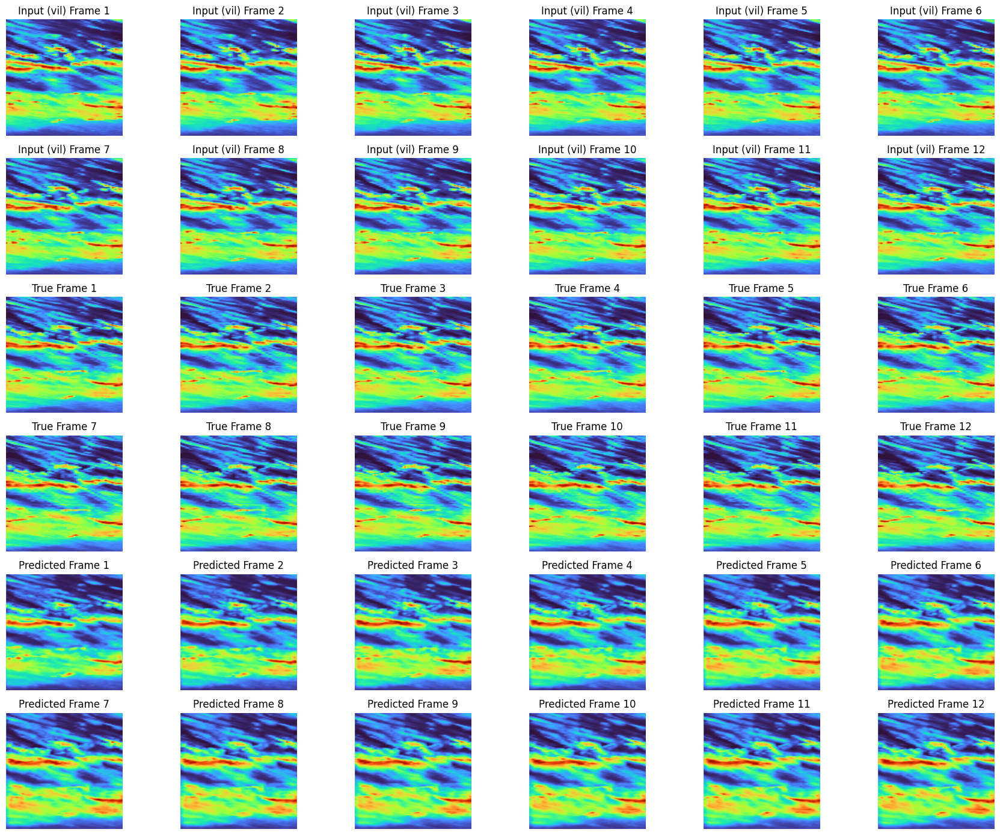

In [ ]:
num_frames = 12
frames_per_row = 6

plt.figure(figsize=(18, 14))

for i in range(num_frames):
    # input Frame
    plt.subplot(6, frames_per_row, i + 1)
    plt.title(f"Input (vil) Frame {i + 1}")
    plt.imshow(X_test[0, i, :, :, 3], cmap="turbo")  # `vil` the forth channel
    plt.axis("off")

    # True Frame
    plt.subplot(6, frames_per_row, frames_per_row * 2 + i + 1)
    plt.title(f"True Frame {i + 1}")
    plt.imshow(Y_test_denorm[0, i, :, :, 0], cmap="turbo")
    plt.axis("off")

    # Predicted Frame
    plt.subplot(6, frames_per_row, frames_per_row * 4 + i + 1)
    plt.title(f"Predicted Frame {i + 1}")
    plt.imshow(Y_pred_denorm[0, i, :, :, 0], cmap="turbo")
    plt.axis("off")

plt.tight_layout()
plt.show()


# superised storm prediction

In [ ]:
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="surprise_task1.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="surprise_task2.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="surprise_task3.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="surprise_events1.csv", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="surprise_events2.csv", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="surprise_events3.csv", repo_type="dataset", local_dir="data")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


surprise_task1.h5:   0%|          | 0.00/43.1M [00:00<?, ?B/s]

surprise_task2.h5:   0%|          | 0.00/114M [00:00<?, ?B/s]

surprise_task3.h5:   0%|          | 0.00/135M [00:00<?, ?B/s]

surprise_events1.csv:   0%|          | 0.00/9.85k [00:00<?, ?B/s]

surprise_events2.csv:   0%|          | 0.00/9.84k [00:00<?, ?B/s]

surprise_events3.csv:   0%|          | 0.00/9.85k [00:00<?, ?B/s]

'data/surprise_events3.csv'

In [ ]:
with h5py.File(f'data/surprise_task1.h5','r') as f:
    event = {img_type: f["S844398"][img_type][:] for img_type in ['vis', 'ir069', 'ir107', 'vil']}
for img_type in event:
    print(f"{img_type}: {event[img_type].shape} ({event[img_type].dtype})")
print()
# note: surprise_task1 has only 12 frames - you need to predict the 12 next "vil" frames.

vis: (384, 384, 12) (int16)
ir069: (192, 192, 12) (int16)
ir107: (192, 192, 12) (int16)
vil: (384, 384, 12) (uint8)



In [ ]:
# Define team name
TEAM_NAME = "Irma"

# Normalization function
def min_max_normalize(data):
    min_val = np.min(data)
    max_val = np.max(data)
    return (data - min_val) / (max_val - min_val + 1e-8), min_val, max_val

# Denormalization function
def denormalize(data, min_val, max_val):
    return data * (max_val - min_val + 1e-8) + min_val

# Upsampling function
def upsample(data, target_shape=(384, 384)):
    zoom_factors = (target_shape[0] / data.shape[0], target_shape[1] / data.shape[1])
    return zoom(data, zoom_factors, order=1)

# Load test dataset
test_file = "data/surprise_task1.h5"
with h5py.File(test_file, "r") as f:
    event_ids = list(f.keys())  # Retrieve all event IDs
    print("Total number of events:", len(event_ids))

# Ensure output directory exists
output_dir = "predictions_task1b"
os.makedirs(output_dir, exist_ok=True)

# Process all events
for event_id in event_ids:
    with h5py.File(test_file, "r") as f:
        event = {img_type: f[event_id][img_type][:] for img_type in ['vis', 'ir069', 'ir107', 'vil']}

    print(f"Processing event {event_id}...")

    # Normalize the data
    vis_norm, vis_min, vis_max = min_max_normalize(event["vis"])
    ir069_norm, ir069_min, ir069_max = min_max_normalize(event["ir069"])
    ir107_norm, ir107_min, ir107_max = min_max_normalize(event["ir107"])
    vil_norm, vil_min, vil_max = min_max_normalize(event["vil"])

    # Upsample ir069 and ir107 to (384, 384)
    ir069_up = np.array([upsample(frame) for frame in np.moveaxis(ir069_norm, -1, 0)])  # Shape: (12, 384, 384)
    ir107_up = np.array([upsample(frame) for frame in np.moveaxis(ir107_norm, -1, 0)])  # Shape: (12, 384, 384)

    # Prepare input data (12, 384, 384, 4)
    X_test = np.stack([
        np.moveaxis(vis_norm, -1, 0),  # (12, 384, 384)
        ir069_up,  # (12, 384, 384)
        ir107_up,  # (12, 384, 384)
        np.moveaxis(vil_norm, -1, 0)  # (12, 384, 384)
    ], axis=-1)  # Shape: (12, 384, 384, 4)

    # Add batch dimension
    X_test = np.expand_dims(X_test, axis=0)  # Shape: (1, 12, 384, 384, 4)
    print("Input X_test shape:", X_test.shape)

    # Load the model
    model = load_model("unet_convlstm_model.keras", custom_objects={"RecursiveLSTMLayer": RecursiveLSTMLayer, "attention": attention})

    # Make predictions
    Y_pred = model.predict(X_test)  # Shape: (1, 12, 384, 384, 1)
    print("Output Y_pred shape:", Y_pred.shape)

    # Denormalize the predicted output
    Y_pred = np.squeeze(Y_pred, axis=0)  # Shape: (12, 384, 384, 1) → (12, 384, 384)
    Y_pred = denormalize(Y_pred, vil_min, vil_max)
    Y_pred = np.squeeze(Y_pred, axis=-1)  # Shape: (12, 384, 384)

    # Convert shape from (12, 384, 384) to (384, 384, 12)
    Y_pred = np.transpose(Y_pred, (1, 2, 0))  # Swap axes to place the time dimension last
    print("Final Y_pred shape:", Y_pred.shape)

    # Save predictions for Task 1B
    filename = f"{TEAM_NAME}-task1b-vil-{event_id}.npy"
    np.save(os.path.join(output_dir, filename), Y_pred.astype(np.float32))

print(f"All events processed successfully. Predictions saved in {output_dir}.")


Total number of events: 10
Processing event S837416...
Input X_test shape: (1, 12, 384, 384, 4)
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Output Y_pred shape: (1, 12, 384, 384, 1)
Final Y_pred shape: (384, 384, 12)
Processing event S843931...
Input X_test shape: (1, 12, 384, 384, 4)
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Output Y_pred shape: (1, 12, 384, 384, 1)
Final Y_pred shape: (384, 384, 12)
Processing event S844398...
Input X_test shape: (1, 12, 384, 384, 4)
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Output Y_pred shape: (1, 12, 384, 384, 1)
Final Y_pred shape: (384, 384, 12)
Processing event S849444...
Input X_test shape: (1, 12, 384, 384, 4)
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Output Y_pred shape: (1, 12, 384, 384, 1)
Final Y_pred shape: (384, 384, 12)
Processing event S849552...
Input X_test shape: (1, 12, 384, 384, 4)
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Output Y_pred shape: (1, 12, 384, 384, 1)
Final Y_pred shape: (384, 384, 12)
Processing event S851111...
Input X_test shape: (1, 12, 384, 38

Total events: 10


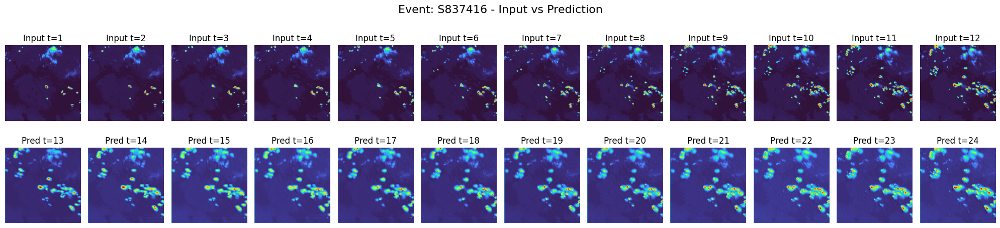

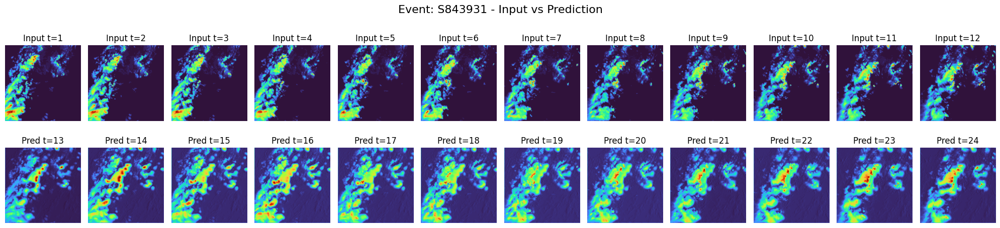

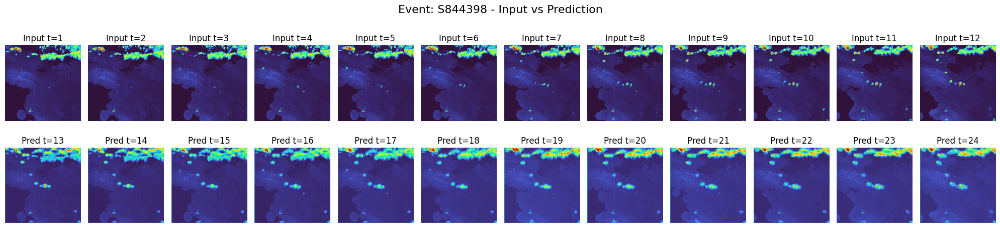

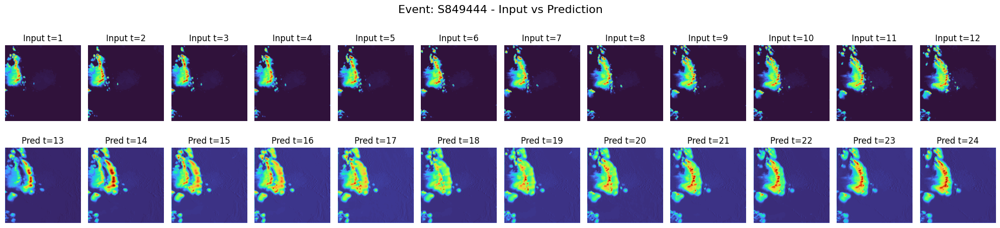

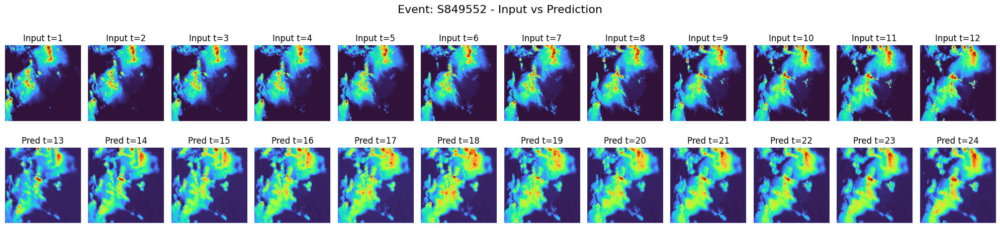

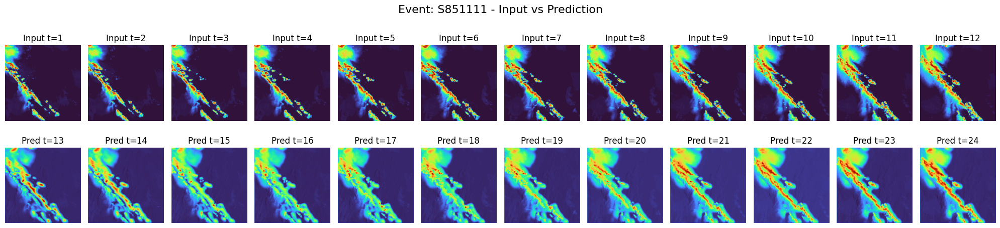

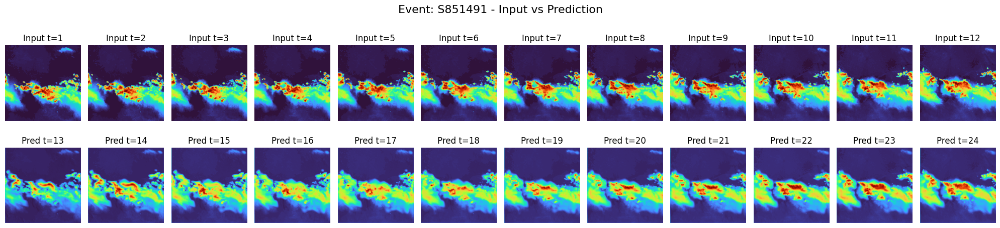

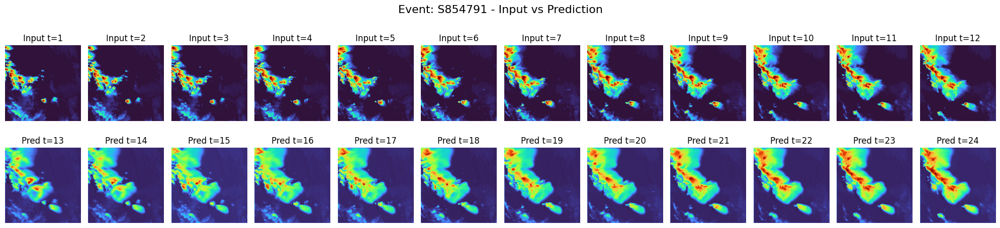

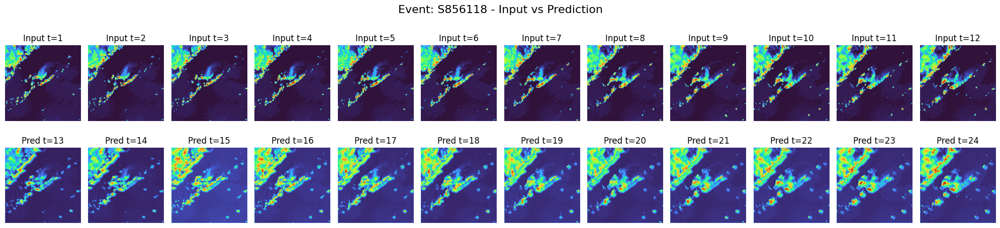

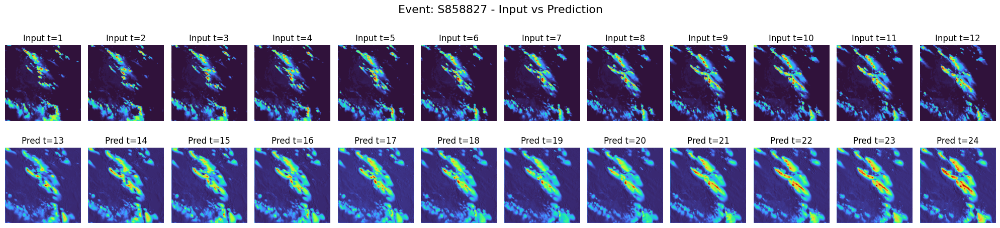

In [ ]:
# Define team name
TEAM_NAME = "myteam"
PREDICTIONS_DIR = "predictions_task1b"

# **1 Load test data from HDF5**
test_file = "data/surprise_task1.h5"
with h5py.File(test_file, "r") as f:
    event_ids = list(f.keys())  # Get all event IDs
    print("Total events:", len(event_ids))

# **2 Load predictions from .npy files**
predictions = {}
for event_id in event_ids:
    pred_file = os.path.join(PREDICTIONS_DIR, f"{TEAM_NAME}-task1b-vil-{event_id}.npy")
    if os.path.exists(pred_file):
        predictions[event_id] = np.load(pred_file)  # Shape: (384, 384, 12)
    else:
        print(f"Warning: Missing prediction file for event {event_id}")

# **3 Plot comparison**
for event_id in event_ids:
    with h5py.File(test_file, "r") as f:
        vil_test = f[event_id]["vil"][:]  # Shape: (384, 384, 12)

    if event_id not in predictions:
        print(f"Skipping event {event_id}, no prediction available.")
        continue

    vil_pred = predictions[event_id]  # Shape: (384, 384, 12)

    fig, axes = plt.subplots(2, 12, figsize=(20, 5))  # 2 rows, 12 columns

    for t in range(12):
        # **Plot previous frames**
        axes[0, t].imshow(vil_test[:, :, t], cmap="turbo")
        axes[0, t].axis("off")
        axes[0, t].set_title(f"Input t={t+1}")

        # **Plot Prediction**
        axes[1, t].imshow(vil_pred[:, :, t], cmap="turbo")
        axes[1, t].axis("off")
        axes[1, t].set_title(f"Pred t={t+13}")

    plt.suptitle(f"Event: {event_id} - Input vs Prediction", fontsize=16)
    plt.tight_layout()
    plt.show()


**Analysis**
<br>
The training loss is consistently higher than the validation loss, which could indicate that the model generalizes well on unseen data. The validation MAE decreases, which is a good sign, but the fluctuations might indicate sensitivity to different batches or possible overfitting starting to emerge.
<br><br>
- There is a relatively smooth transition from input frame 12 to predicted frame 1.
- Although the changes in the final predicted frames are not very large, the model is able to capture the pattern variations within the red box.
- However, the predicted images still exhibit higher saturation, with colors appearing more vivid compared to the original.

